In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.feature_selection import VarianceThreshold,RFE, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
fold_1_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [5]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [19]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

xgb_model.fit(X_train_scaled, y_train)

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:29:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [12]:
# Get fraud probabilities
rf_probs = rf_model.predict_proba(X_val_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]

In [ ]:
# Blending (adjust weights as needed)
blended_probs = 0.5 * rf_probs + 0.5 * xgb_probs

# Convert to binary prediction with threshold
threshold = 0.5  # Tune this if needed
blended_preds = (blended_probs >= threshold).astype(int)

In [ ]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Metrics dictionary
    metrics = {}

    # F1-Score (useful for fraud detection tasks)
    f1 = f1_score(y_true, y_pred)
    metrics['f1_score'] = f1
    print(f"F1-Score: {f1:.4f}")

    # Precision and Recall (for both classes)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    metrics['precision'] = precision
    metrics['recall'] = recall
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # If probabilities are provided, plot Precision-Recall curve
    if y_proba is not None and plot_pr_curve:
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return metrics


 Classification Report:
              precision    recall  f1-score   support

           0     0.9924    0.9983    0.9953    178711
           1     0.6384    0.2859    0.3950      1920

    accuracy                         0.9907    180631
   macro avg     0.8154    0.6421    0.6951    180631
weighted avg     0.9886    0.9907    0.9889    180631

Confusion Matrix:
[[178400    311]
 [  1371    549]]
Accuracy: 0.9906881985927111
AUC-PR (Average Precision): 0.5192
ROC AUC: 0.9740


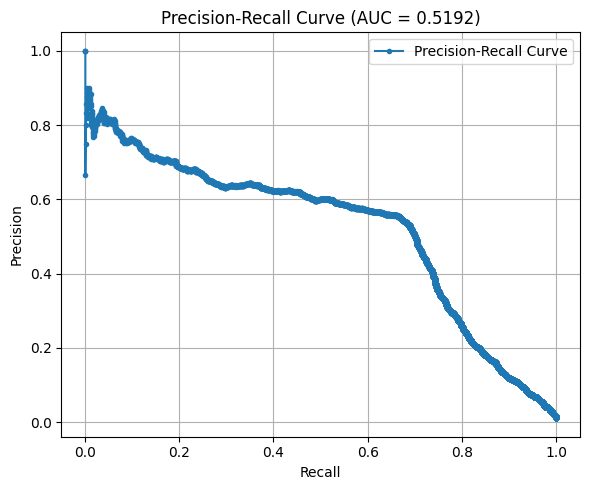

In [24]:
# Evaluate ensemble model
metrics = evaluate_model(y_val, blended_preds, y_proba=blended_probs, plot_pr_curve=True)

### Optuna Hyperparameter Tuning

In [8]:
# Sample 1 million rows while preserving the 50/50 balance
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

In [ ]:
def objective(trial):
    # Random Forest hyperparameters
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 3, 20)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 20)

    # XGBoost hyperparameters
    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)
    xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 15)
    xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.3)
    xgb_subsample = trial.suggest_float('xgb_subsample', 0.5, 1.0)
    xgb_colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)

    # Blending weight
    blend_weight = trial.suggest_float('blend_weight', 0.1, 0.9)

    # Initialize models
    rf = RandomForestClassifier(
        n_estimators=rf_n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        n_estimators=xgb_n_estimators,
        max_depth=xgb_max_depth,
        learning_rate=xgb_learning_rate,
        subsample=xgb_subsample,
        colsample_bytree=xgb_colsample_bytree,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    # Train on the sampled training data
    rf.fit(X_train_sample, y_train_sample)
    xgb.fit(X_train_sample, y_train_sample)

    # Predict on the validation set (not train!)
    rf_probs = rf.predict_proba(X_val_scaled)[:, 1]
    xgb_probs = xgb.predict_proba(X_val_scaled)[:, 1]

    # Blend predictions
    blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

    # Score using F1 Score on validation
    f1 = f1_score(y_val, blended_preds)

    return f1

# Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)

# Best results
print("\nBest AUC-PR:", study.best_value)
print("Best Hyperparameters:", study.best_params)

[I 2025-04-08 11:18:38,211] A new study created in memory with name: no-name-94372e86-1504-484b-b35c-315f29f5fcbe


  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:24:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-08 11:25:19,263] Trial 0 finished with value: 0.15467648903996228 and parameters: {'rf_n_estimators': 197, 'rf_max_depth': 18, 'rf_min_samples_split': 7, 'xgb_n_estimators': 181, 'xgb_max_depth': 4, 'xgb_learning_rate': 0.10017568835418089, 'xgb_subsample': 0.9996465834363297, 'xgb_colsample_bytree': 0.5027932858212243, 'blend_weight': 0.14613525724537502}. Best is trial 0 with value: 0.15467648903996228.


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:30:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


...

[I 2025-04-08 11:58:27,340] Trial 7 finished with value: 0.09897276365638011 and parameters: {'rf_n_estimators': 143, 'rf_max_depth': 9, 'rf_min_samples_split': 17, 'xgb_n_estimators': 181, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.049617193887135, 'xgb_subsample': 0.8130560041345383, 'xgb_colsample_bytree': 0.8781266414999136, 'blend_weight': 0.4440736051700237}. Best is trial 6 with value: 0.6899755291173979.


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:01:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-08 12:02:18,237] Trial 8 finished with value: 0.45798112372136734 and parameters: {'rf_n_estimators': 266, 'rf_max_depth': 4, 'rf_min_samples_split': 7, 'xgb_n_estimators': 196, 'xgb_max_depth': 15, 'xgb_learning_rate': 0.1978707353226543, 'xgb_subsample': 0.8219576385298332, 'xgb_colsample_bytree': 0.8335303664229601, 'blend_weight': 0.28108694474202844}. Best is trial 6 with value: 0.6899755291173979.


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:03:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-08 12:04:16,615] Trial 9 finished with value: 0.615880888165559 and parameters: {'rf_n_estimators': 72, 'rf_max_depth': 9, 'rf_min_samples_split': 4, 'xgb_n_estimators': 153, 'xgb_max_depth': 14, 'xgb_learning_rate': 0.2144022455193575, 'xgb_subsample': 0.617410545776065, 'xgb_colsample_bytree': 0.623446849595337, 'blend_weight': 0.568926370074457}. Best is trial 6 with value: 0.6899755291173979.

Best AUC-PR: 0.6899755291173979
Best Hyperparameters: {'rf_n_estimators': 196, 'rf_max_depth': 17, 'rf_min_samples_split': 3, 'xgb_n_estimators': 177, 'xgb_max_depth': 15, 'xgb_learning_rate': 0.16915574850353113, 'xgb_subsample': 0.7968513850333873, 'xgb_colsample_bytree': 0.5983934136254612, 'blend_weight': 0.7232785295377558}


In [20]:
best_params = study.best_params

# Re-initialize models using best parameters
best_rf = RandomForestClassifier(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    min_samples_split=best_params['rf_min_samples_split'],
    random_state=42,
    n_jobs=-1
)

best_xgb = XGBClassifier(
    n_estimators=best_params['xgb_n_estimators'],
    max_depth=best_params['xgb_max_depth'],
    learning_rate=best_params['xgb_learning_rate'],
    subsample=best_params['xgb_subsample'],
    colsample_bytree=best_params['xgb_colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [21]:
best_rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=17, min_samples_split=3, n_estimators=196,
                       n_jobs=-1, random_state=42)

In [22]:
best_xgb.fit(X_train_scaled, y_train)

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:50:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5983934136254612, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.16915574850353113,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=177, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)


 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    178711
           1     1.0000    1.0000    1.0000      1920

    accuracy                         1.0000    180631
   macro avg     1.0000    1.0000    1.0000    180631
weighted avg     1.0000    1.0000    1.0000    180631

Confusion Matrix:
[[178711      0]
 [     0   1920]]
Accuracy: 1.0
AUC-PR (Average Precision): 1.0000
ROC AUC: 1.0000


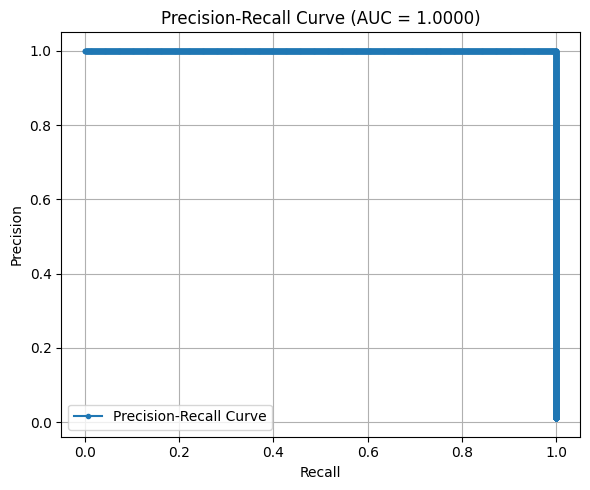

{'auc_pr': np.float64(1.0), 'roc_auc': np.float64(1.0)}

In [25]:
# Predict probabilities on validation set
rf_probs_best = best_rf.predict_proba(X_val_scaled)[:, 1]
xgb_probs_best = best_xgb.predict_proba(X_val_scaled)[:, 1]

# Blend with optimal weight from Optuna
blend_weight = best_params['blend_weight']
blended_probs_best = (1 - blend_weight) * rf_probs_best + blend_weight * xgb_probs_best

# Binarize using threshold = 0.5
blended_preds_best = (blended_probs_best >= 0.5).astype(int)

# Evaluate
evaluate_model(y_val, blended_preds_best, blended_probs_best)